In [1]:
!pip install kaggle

In [2]:
import json
#username和key改为自己的kaggle的，如果不行，就可以直接用这个
token = {"username":"ykz","key":"KGAT_851a5fffd594ad4afe4b9a3d209308da"}
with open('/content/kaggle.json', 'w') as file:
  json.dump(token, file)#json.dump类似于write

In [3]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle config set -n path -v /content

- path is now set to: /content


In [4]:
!kaggle datasets download -d slothkong/10-monkey-species

Dataset URL: https://www.kaggle.com/datasets/slothkong/10-monkey-species
License(s): CC0-1.0
 99% 544M/547M [00:12<00:00, 25.2MB/s]
100% 547M/547M [00:12<00:00, 47.4MB/s]


In [5]:
!ls -lh datasets/slothkong/10-monkey-species/

total 548M
-rw-r--r-- 1 root root 548M Sep 26  2019 10-monkey-species.zip


In [6]:
!ls

datasets  kaggle.json  sample_data


In [7]:
!pwd

/content


In [8]:
!unzip -o -d /content /content/datasets/slothkong/10-monkey-species/10-monkey-species.zip

Archive:  /content/datasets/slothkong/10-monkey-species/10-monkey-species.zip
  inflating: /content/monkey_labels.txt  
  inflating: /content/training/training/n0/n0018.jpg  
  inflating: /content/training/training/n0/n0019.jpg  
  inflating: /content/training/training/n0/n0020.jpg  
  inflating: /content/training/training/n0/n0021.jpg  
  inflating: /content/training/training/n0/n0022.jpg  
  inflating: /content/training/training/n0/n0023.jpg  
  inflating: /content/training/training/n0/n0024.jpg  
  inflating: /content/training/training/n0/n0025.jpg  
  inflating: /content/training/training/n0/n0026.jpg  
  inflating: /content/training/training/n0/n0027.jpg  
  inflating: /content/training/training/n0/n0028.jpg  
  inflating: /content/training/training/n0/n0029.jpg  
  inflating: /content/training/training/n0/n0030.jpg  
  inflating: /content/training/training/n0/n0031.jpg  
  inflating: /content/training/training/n0/n0032.jpg  
  inflating: /content/training/training/n0/n0033.jpg  


In [9]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)
matplotlib 3.10.0
numpy 2.0.2
pandas 2.2.2
sklearn 1.6.1
torch 2.9.0+cu126
cuda:0


In [10]:
!ls  /content/training/training

n0  n1	n2  n3	n4  n5	n6  n7	n8  n9


In [11]:
!ls /content/validation/

validation


# 数据预处理

In [12]:
# INSERT_YOUR_CODE
from torchvision import datasets, transforms
import os

# 设置数据目录
data_dir = '/content/'

# 定义预处理: resize到128x128, 转为tensor
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4363, 0.4328, 0.3291], std=[0.2427, 0.2382, 0.2413])
])

# 读取训练集和测试集
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'training/training'), transform=transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'validation/validation'), transform=transform)

# 获取类别名（方便后续显示标签）
class_names = train_dataset.classes
class_names

['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']

# 数据预处理

In [13]:
len(train_dataset)

1097

In [14]:
train_dataset[0][0].shape #特征

torch.Size([3, 128, 128])

In [15]:
train_dataset[0][1] #标签

0

In [16]:
len(test_dataset)

272

In [ ]:
# INSERT_YOUR_CODE

# from torch.utils.data import DataLoader
# import torch

# loader = DataLoader(train_dataset, batch_size=64, shuffle=False, num_workers=2)

# mean = torch.zeros(3)
# std = torch.zeros(3)
# n_pixels = 0

# for images, _ in loader:  # images: [B, 3, 128, 128]
#     batch_pixels = images.numel() // 3  # total pixels per channel
#     mean += images.sum(dim=[0, 2, 3])
#     std  += (images ** 2).sum(dim=[0, 2, 3])
#     n_pixels += batch_pixels

# mean /= n_pixels
# std = torch.sqrt(std / n_pixels - mean ** 2)

# print("按通道均值:", mean)
# print("按通道标准差:", std)



In [17]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
    num_workers=2  # 使用多进程加载数据
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
    num_workers=2
)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个批次的数据
train_iter = iter(train_loader)
batch_images, batch_labels = next(train_iter)
print(f"批次图像张量形状: {batch_images.shape}")
print(f"批次标签张量形状: {batch_labels.shape}")
print(batch_labels)

训练集DataLoader批次数: 35
测试集DataLoader批次数: 9
每个批次大小: 32
批次图像张量形状: torch.Size([32, 3, 128, 128])
批次标签张量形状: torch.Size([32])
tensor([9, 2, 4, 0, 4, 0, 3, 8, 9, 9, 6, 9, 8, 8, 5, 6, 3, 4, 2, 6, 4, 2, 1, 1,
        9, 3, 0, 0, 0, 4, 8, 7])


In [ ]:
28*28

784

在PyTorch中，`DataLoader`是一个迭代器，它封装了数据的加载和预处理过程，使得在训练机器学习模型时可以方便地批量加载数据。`DataLoader`主要负责以下几个方面：

1. **批量加载数据**：`DataLoader`可以将数据集（Dataset）切分为更小的批次（batch），每次迭代提供一小批量数据，而不是单个数据点。这有助于模型学习数据中的统计依赖性，并且可以更高效地利用GPU等硬件的并行计算能力。

2. **数据打乱**：默认情况下，`DataLoader`会在每个epoch（训练周期）开始时打乱数据的顺序。这有助于模型训练时避免陷入局部最优解，并且可以提高模型的泛化能力。

3. **多线程数据加载**：`DataLoader`支持多线程（通过参数`num_workers`）来并行地加载数据，这可以显著减少训练过程中的等待时间，尤其是在处理大规模数据集时。

4. **数据预处理**：`DataLoader`可以与`transforms`结合使用，对加载的数据进行预处理，如归一化、标准化、数据增强等操作。

5. **内存管理**：`DataLoader`负责管理数据的内存使用，确保在训练过程中不会耗尽内存资源。

6. **易用性**：`DataLoader`提供了一个简单的接口，可以很容易地集成到训练循环中。

# 搭建模型

In [ ]:
128//8

16

In [18]:
from torchvision.models import resnet50

class ResNet50(nn.Module):
    def __init__(self, num_classes=10, frozen=True):
        super().__init__()
        # 下载预训练权重
        self.model = resnet50(weights='IMAGENET1K_V2')
        # 冻结所有参数
        if frozen:
            for param in self.model.parameters():
                param.requires_grad = False
        # 对layer4进行解冻
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        # 替换最后一层fc为10分类
        in_features = self.model.fc.in_features #2048
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

model=ResNet50()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s]


In [ ]:
128*16*16*256

8388608

In [20]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确
import torch

dummy_input = torch.randn(32, 3, 128, 128)
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")


Output shape: torch.Size([32, 10])


In [21]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量


各层参数量统计：
model.layer4.0.conv1.weight: 524288
model.layer4.0.bn1.weight: 512
model.layer4.0.bn1.bias: 512
model.layer4.0.conv2.weight: 2359296
model.layer4.0.bn2.weight: 512
model.layer4.0.bn2.bias: 512
model.layer4.0.conv3.weight: 1048576
model.layer4.0.bn3.weight: 2048
model.layer4.0.bn3.bias: 2048
model.layer4.0.downsample.0.weight: 2097152
model.layer4.0.downsample.1.weight: 2048
model.layer4.0.downsample.1.bias: 2048
model.layer4.1.conv1.weight: 1048576
model.layer4.1.bn1.weight: 512
model.layer4.1.bn1.bias: 512
model.layer4.1.conv2.weight: 2359296
model.layer4.1.bn2.weight: 512
model.layer4.1.bn2.bias: 512
model.layer4.1.conv3.weight: 1048576
model.layer4.1.bn3.weight: 2048
model.layer4.1.bn3.bias: 2048
model.layer4.2.conv1.weight: 1048576
model.layer4.2.bn1.weight: 512
model.layer4.2.bn1.bias: 512
model.layer4.2.conv2.weight: 2359296
model.layer4.2.bn2.weight: 512
model.layer4.2.bn2.bias: 512
model.layer4.2.conv3.weight: 1048576
model.layer4.2.bn3.weight: 2048
model.layer4.2.bn3.

In [ ]:
32*3*3*64

18432

# 训练

In [22]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [24]:
import wangdao_train
# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100
)

# 设定训练轮数
num_epochs = 20

# 开始训练
trainer.train(num_epochs)


Epoch [1/20]  Train Loss: 0.6516  Train Acc: 0.8186
Epoch [2/20]  Train Loss: 0.1437  Train Acc: 0.9663
[Step 100] Val Loss: 0.0563 Val Acc: 0.9816
Epoch [3/20]  Train Loss: 0.0424  Train Acc: 0.9900
Epoch [4/20]  Train Loss: 0.0481  Train Acc: 0.9900
Epoch [5/20]  Train Loss: 0.0368  Train Acc: 0.9954
[Step 200] Val Loss: 0.0771 Val Acc: 0.9743
Epoch [6/20]  Train Loss: 0.0114  Train Acc: 0.9964
Epoch [7/20]  Train Loss: 0.0343  Train Acc: 0.9936
Epoch [8/20]  Train Loss: 0.0124  Train Acc: 0.9973
[Step 300] Val Loss: 0.0993 Val Acc: 0.9596
Epoch [9/20]  Train Loss: 0.0251  Train Acc: 0.9936
Epoch [10/20]  Train Loss: 0.0245  Train Acc: 0.9936
Epoch [11/20]  Train Loss: 0.0272  Train Acc: 0.9909
[Step 400] Val Loss: 0.0733 Val Acc: 0.9669
Epoch [12/20]  Train Loss: 0.0044  Train Acc: 0.9991
Epoch [13/20]  Train Loss: 0.0193  Train Acc: 0.9954
Epoch [14/20]  Train Loss: 0.0143  Train Acc: 0.9954
[Step 500] Val Loss: 0.1357 Val Acc: 0.9632
Epoch [15/20]  Train Loss: 0.6773  Train Acc: 0

In [26]:
trainer.train(num_epochs)

Epoch [1/20]  Train Loss: 0.0084  Train Acc: 0.9991
Epoch [2/20]  Train Loss: 0.0037  Train Acc: 0.9991
[Step 100] Val Loss: 0.0914 Val Acc: 0.9706
Epoch [3/20]  Train Loss: 0.0085  Train Acc: 0.9973
Epoch [4/20]  Train Loss: 0.0023  Train Acc: 0.9991
Epoch [5/20]  Train Loss: 0.0018  Train Acc: 1.0000
[Step 200] Val Loss: 0.0740 Val Acc: 0.9779
Epoch [6/20]  Train Loss: 0.0008  Train Acc: 1.0000
Epoch [7/20]  Train Loss: 0.0062  Train Acc: 0.9964
Epoch [8/20]  Train Loss: 0.0036  Train Acc: 0.9991
[Step 300] Val Loss: 0.0559 Val Acc: 0.9853
Epoch [9/20]  Train Loss: 0.0008  Train Acc: 1.0000
Epoch [10/20]  Train Loss: 0.0006  Train Acc: 1.0000
Epoch [11/20]  Train Loss: 0.0010  Train Acc: 1.0000
[Step 400] Val Loss: 0.0437 Val Acc: 0.9926
Epoch [12/20]  Train Loss: 0.0002  Train Acc: 1.0000
Epoch [13/20]  Train Loss: 0.0005  Train Acc: 1.0000
Epoch [14/20]  Train Loss: 0.0006  Train Acc: 1.0000
[Step 500] Val Loss: 0.0363 Val Acc: 0.9926
Epoch [15/20]  Train Loss: 0.0000  Train Acc: 1

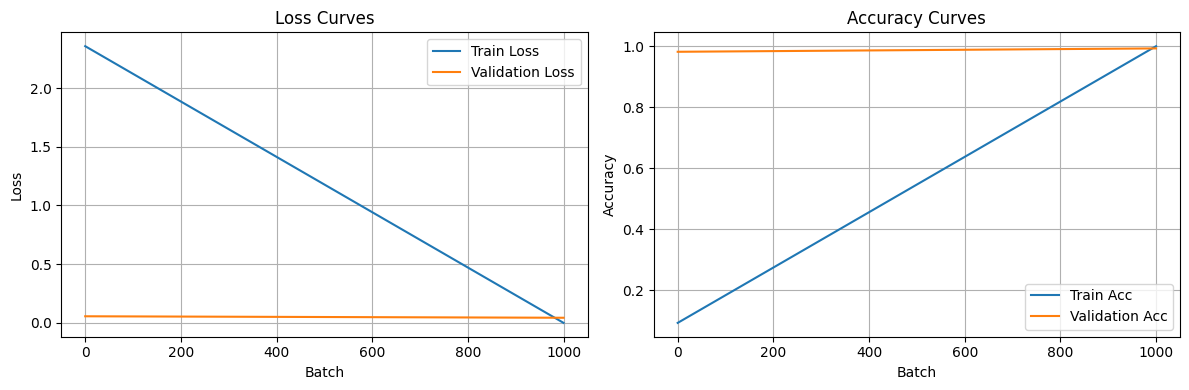

In [27]:
trainer.plot_curves()
